In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

#setting visulization style
plt.style.use('seaborn-v0_8')
sns.set_palette('husl')
print("All libraries imported successfully")

All libraries imported successfully


In [2]:
df = pd.read_csv('retail_sales (1).csv')

In [3]:
df.head(10)

,Date,Category,Sales,Quantity,Profit,Region
0,1/1/2023,Electronics,1149.014246,11.0,383.664245,North
1,1/1/2023,Clothing,958.520710,7.0,224.054049,East
2,1/1/2023,Home Goods,1473.763845,2.0,466.593090,South
3,1/1/2023,Sports,1230.230419,6.0,123.310460,West
4,1/1/2023,NaN?,828.585950,12.0,88.591355,East
5,1/2/2023,Electronics,722.775149,10.0,82.396149,West
6,1/2/2023,Clothing,788.996859,15.0,225.271072,West
7,1/2/2023,Home Goods,358.113803,3.0,128.198339,East
8,1/2/2023,Sports,819.923845,2.0,250.298077,East
9,1/2/2023,Books,1284.231946,7.0,363.436353,West


In [4]:
print("== Data Set Basic Information ==")
print(f'Data Set Dimensions: {df.shape[0]} rows x {df.shape[1]} columns')
print('\nColumns Name and datatypes')
print(df.dtypes)

== Data Set Basic Information ==
Data Set Dimensions: 1825 rows x 6 columns

Columns Name and datatypes
Date         object
Category     object
Sales       float64
Quantity    float64
Profit      float64
Region       object
dtype: object


In [5]:
print('\nMissing values:')
print(df.isnull().sum())
print('\nDataSet Summary:')
df.info()


Missing values:
Date        0
Category    4
Sales       2
Quantity    5
Profit      0
Region      5
dtype: int64

DataSet Summary:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1825 entries, 0 to 1824
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Date      1825 non-null   object 
 1   Category  1821 non-null   object 
 2   Sales     1823 non-null   float64
 3   Quantity  1820 non-null   float64
 4   Profit    1825 non-null   float64
 5   Region    1820 non-null   object 
dtypes: float64(3), object(3)
memory usage: 85.7+ KB


In [6]:
df['Region'] = df['Region'].fillna(df["Region"].mode()[0])

In [7]:
df['Category'] = df['Category'].fillna(df["Category"].mode()[0])

In [8]:
df['Sales'] = pd.to_numeric(df['Sales'])
df['Sales'] = df['Sales'].fillna(df['Sales'].mode()[0])

In [9]:
df['Quantity'] = pd.to_numeric(df['Quantity'])
df['Quantity'] = df['Quantity'].fillna(df['Quantity'].mode()[0])

In [10]:
print('\nMissing values:')
print(df.isnull().sum())


Missing values:
Date        0
Category    0
Sales       0
Quantity    0
Profit      0
Region      0
dtype: int64


In [11]:
print("== Data Cleaning and type conversion ==")

#date to date time format
df['Date'] = pd.to_datetime(df['Date'])

#Extract additional time features 
df['Month'] = df['Date'].dt.month
df['Quarter'] = df['Date'].dt.quarter
df['DayOfWeek'] = df['Date'].dt.day_name()
df['MonthName'] = df['Date'].dt.month_name()

#Ensuring numeric columns are properly formatted 
numeric_columns = df[['Sales', 'Quantity', 'Profit']]
for col in numeric_columns:
    df['col'] = pd.to_numeric(df[col], errors='coerce')

print("DateTypes after conversions:")
print(df.dtypes)
print(f'\nDate range: {df['Date'].min()} to {df['Date'].max()}')

== Data Cleaning and type conversion ==
DateTypes after conversions:
Date         datetime64[ns]
Category             object
Sales               float64
Quantity            float64
Profit              float64
Region               object
Month                 int32
Quarter               int32
DayOfWeek            object
MonthName            object
col                 float64
dtype: object

Date range: 2023-01-01 00:00:00 to 2023-12-31 00:00:00


In [12]:
print("==Statistical Summary==")
print('For Numerical Columns')
print(df[['Sales','Quantity','Profit']].describe())

==Statistical Summary==
For Numerical Columns
             Sales     Quantity       Profit
count  1825.000000  1825.000000  1825.000000
mean    979.408176    10.067397   248.696130
std     338.132555     5.513874   118.159627
min       0.000000     0.000000     0.000000
25%     782.926023     5.000000   156.916498
50%     996.596443    10.000000   229.344557
75%    1208.163533    15.000000   324.867847
max    1888.932537    19.000000   703.228418


In [13]:
print('\nCategory wise summary:')
category_summary = df.groupby('Category').agg({
    'Sales' : ['count','mean','sum','std'],
    'Profit' : ['sum','mean'],
    'Quantity':['sum','mean']
}).round(2)
print(category_summary)


Category wise summary:
            Sales                                Profit         Quantity  \
            count     mean        sum     std       sum    mean      sum   
Category                                                                   
Books         364  1019.15  370971.87  336.39  92304.45  253.58   3737.0   
Clothing      369   963.20  355420.13  336.42  90889.44  246.31   3670.0   
Electronics   361  1008.56  364090.41  347.87  90439.70  250.53   3595.0   
Home Goods    364   954.65  347493.83  332.39  87447.82  240.24   3777.0   
NaN?            1   828.59     828.59     NaN     88.59   88.59     12.0   
Nan             1   823.19     823.19     NaN    253.43  253.43      4.0   
Null            1  1106.85    1106.85     NaN    381.78  381.78     11.0   
Sports        364   952.43  346685.06  334.51  92065.22  252.93   3567.0   

                    
              mean  
Category            
Books        10.27  
Clothing      9.95  
Electronics   9.96  
Home Goods   

In [16]:
print('\nRegion wise summary:')
region_summary = df.groupby('Region').agg({
    'Sales' : ['count','mean','sum','std'],
    'Profit' : ['sum','mean'],
    'Quantity':['sum','mean']
}).round(2)
print(region_summary)


Region wise summary:
       Sales                                 Profit         Quantity       
       count     mean        sum     std        sum    mean      sum   mean
Region                                                                     
East     398   988.55  393441.61  322.67   98973.62  248.68   4133.0  10.38
Nan        1  1716.71    1716.71     NaN     545.62  545.62      8.0   8.00
North    460   974.55  448295.03  317.59  112126.47  243.75   4704.0  10.23
South    489   968.20  473452.19  360.90  119706.95  244.80   4845.0   9.91
West     477   986.40  470514.37  345.06  122517.78  256.85   4683.0   9.82


In [14]:
print('==Monthly Sales Trend Analysis==')

#Calculate Monthly Sales
monthly_sales = df.groupby(['Month','MonthName']).agg({
    'Sales': ['sum'],
    'Profit' : ['sum'],
    'Quantity' : ['sum']
}).reset_index()

monthly_sales = monthly_sales.sort_values('Month')
print('Monthly Sales Summary: ')
print(monthly_sales)

==Monthly Sales Trend Analysis==
Monthly Sales Summary: 
   Month  MonthName          Sales        Profit Quantity
                               sum           sum      sum
0      1    January  147068.619477  39711.436221   1561.0
1      2   February  132215.411776  34353.123612   1517.0
2      3      March  145321.200626  38584.599285   1447.0
3      4      April  138160.991209  37895.203187   1446.0
4      5        May  150774.977103  40527.689566   1603.0
5      6       June  152605.749860  39042.686605   1570.0
6      7       July  162111.115687  40208.956109   1536.0
7      8     August  148020.452251  34675.627875   1489.0
8      9  September  153094.700793  37796.761379   1598.0
9     10    October  151272.280840  36019.384158   1569.0
10    11   November  146795.613628  36344.048332   1461.0
11    12   December  159978.807192  38710.920857   1576.0


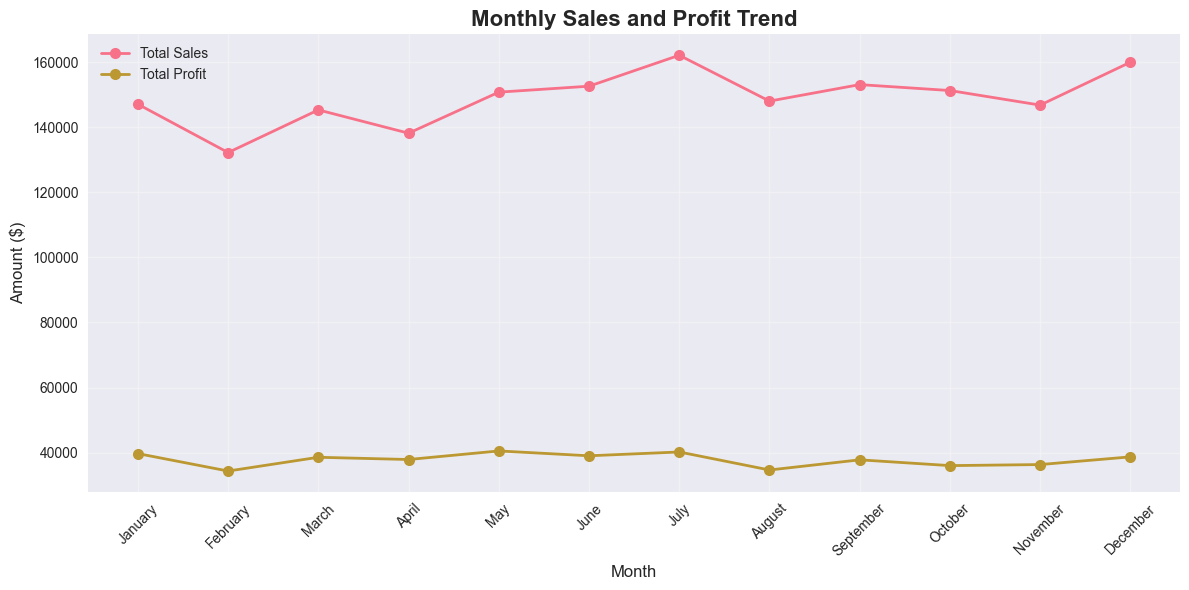

In [18]:
plt.figure(figsize=(12,6))
plt.plot(monthly_sales['MonthName'], monthly_sales['Sales'],
        marker = 'o', linewidth=2, markersize=8, label= 'Total Sales')
plt.plot(monthly_sales['MonthName'], monthly_sales['Profit'],
        marker = 'o', linewidth=2, markersize=8, label= 'Total Profit')
plt.title('Monthly Sales and Profit Trend', fontsize = 16, fontweight='bold')
plt.xlabel('Month', fontsize=12)
plt.ylabel('Amount ($)', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [22]:
#Performance Analysis
print('==Category Performance Analysis==')
category_performance = df.groupby('Category').agg({
    'Sales': 'sum',
    'Profit' :'sum',
    'Quantity' : 'sum'
}).sort_values('Sales', ascending=False)
print("\nCategory Performance (Sorted by sales)")
print(category_performance)

==Category Performance Analysis==

Category Performance (Sorted by sales)
                     Sales        Profit  Quantity
Category                                          
Books        370971.872558  92304.452141    3737.0
Electronics  364090.406288  90439.697795    3595.0
Clothing     355420.126737  90889.437106    3670.0
Home Goods   347493.827088  87447.820056    3777.0
Sports       346685.063298  92065.220851    3567.0
Null           1106.847949    381.784578      11.0
NaN?            828.585950     88.591355      12.0
Nan             823.190573    253.433301       4.0
